# TEAL Graph Exploration

Build a NetworkX `MultiDiGraph` from a TEAL CodeQL database, walk it with standard NetworkX ops, and render slices with Graphviz `dot`.

**Dependencies:** `networkx`, `codeql` on PATH, `dot` (Graphviz) on PATH.

Nodes are typed `AstNode` instances (one subclass per TEAL opcode — see `teal_ast.py`), each carrying a `Location` and the opcode's source `code` (with immediates). The first load does a cold run (~20–30s, compiles three queries); subsequent loads hit a per-db CSV cache.

In [7]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path

# VS Code on WSL can pick up /mnt/c/codeql-win64/codeql first (Windows
# binary, no Linux JRE). Pin the Linux codeql explicitly.
os.environ.setdefault("CODEQL", "/home/argi/tools/codeql/codeql")

HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent.parent))

from tealtools.graphs import (
    load_graph,
    cfg_view, dataflow_view,
    draw_cfg, draw_dataflow, draw,
    to_dot,
    # BB view
    cfg_bb_graph, draw_cfg_bb, to_bb_dot, BasicBlockNode,
    # SSA inspection (graph-attribute API)
    SSAVar, PhiNode,
    stack_inputs, stack_outputs, stack_summary, print_ssa_trace,
    ssa_functional, print_ssa_functional,
)
# Typed SSA program representation (section 14).
import tealtools.ssa as teal_ssa
import tealtools.ast as T
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load a database

Point at any built TEAL CodeQL db. The repo ships two: `tests/dbs/xgov-db` and `tests/dbs/folks-finance-db`.

In [2]:
DB = HERE.parent.parent / "tests" / "dbs" / "xgov-db"
g = load_graph(DB)
g.number_of_nodes(), g.number_of_edges()

[teal_graphs] loaded 1781 nodes, 2744 edges from xgov-db


(1781, 2744)

## 2. Structure of a node

Each node is an `AstNode` instance. Two fields:

- `.location` — a `Location` dataclass (`file`, `start_line`, `start_column`, `end_line`, `end_column`), straight from CodeQL.
- `.code` — the opcode as written in the source, with its immediates (e.g. `"txn NumAppArgs"`, `"bnz main_l14"`).

The Python *class* encodes the opcode type (`TxnOpcode`, `BnzOpcode`, `IntegerAddOpcode`, ...) and sits in a family hierarchy rooted at `AstNode`. Hash/equality are keyed by `(file, start_line)`.

In [8]:
from itertools import islice

for n in islice(g.nodes, 6):
    print(f"{type(n).__name__:20s}  {n.location.file}:{n.location.start_line:>4}  code={n.code!r}")

Source                approval.teal:   1  code=''
IntcblockOpcode       approval.teal:   2  code='intcblock 0 1 10 3'
BytecblockOpcode      approval.teal:   3  code='bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d657461646174615f697066735f636964 0x73746172745f74696d65 0x656e645f74696d65 0x71756f72756d 0x6e66745f696d6167655f75726c 0x4c6bea72 0x151f7c75 0x6e66745f61737365745f6964 0x068101 0x2c'
TxnOpcode             approval.teal:   4  code='txn NumAppArgs'
Intc0Opcode           approval.teal:   5  code='intc_0'
IntegerEqualsOpcode   approval.teal:   6  code='=='


## 3. Typed filtering via isinstance

Every leaf opcode class subclasses a family (`ArithmeticOpcode`, `BranchOpcode`, `ComparisonOpcode`, `StackManipulationOpcode`, ...) which subclasses `Opcode` which subclasses `AstNode`. Filter by whichever level you want.

In [9]:
from collections import Counter

families = [T.ArithmeticOpcode, T.BranchOpcode, T.ComparisonOpcode,
            T.StackManipulationOpcode, T.TransactionOpcode, T.ScratchSpaceOpcode,
            T.GlobalStateOpcode, T.ControlFlowOpcode]

for fam in families:
    count = sum(1 for n in g if isinstance(n, fam))
    print(f"  {fam.__name__:28s}  {count}")

# Most common leaf types:
print("\nTop 10 leaf classes:")
for cls, k in Counter(type(n).__name__ for n in g).most_common(10):
    print(f"  {cls:28s}  {k}")

  ArithmeticOpcode              42
  BranchOpcode                  72
  ComparisonOpcode              89
  StackManipulationOpcode       125
  TransactionOpcode             60
  ScratchSpaceOpcode            166
  GlobalStateOpcode             82
  ControlFlowOpcode             145

Top 10 leaf classes:
  PhiNode                       608
  LoadOpcode                    86
  StoreOpcode                   80
  FrameDigOpcode                77
  Intc0Opcode                   74
  Label                         63
  BytecOpcode                   54
  AssertOpcode                  51
  IntegerEqualsOpcode           50
  PushintOpcode                 36


## 4. Edge kinds

Every edge has `kind` = `"cfg"` or `"dataflow"`. CFG edges additionally carry `successor` (e.g. `NormalSuccessor`, `BooleanSuccessor(true)`, `RetsubCompletion`).

In [10]:
kind_counts = Counter(d["kind"] for _, _, d in g.edges(data=True))
successor_counts = Counter(
    d["successor"] for _, _, d in g.edges(data=True) if d["kind"] == "cfg"
)
print("edges by kind:     ", dict(kind_counts))
print("cfg by successor:  ", dict(successor_counts))

edges by kind:      {'cfg': 2183, 'dataflow': 561}
cfg by successor:   {'NormalSuccessor': 1089, 'BooleanSuccessor(false)': 31, 'BooleanSuccessor(true)': 82, 'PhiIn': 684, 'PhiOut': 297}


## 5. Kind-specific views

`cfg_view(g)` and `dataflow_view(g)` return read-only subgraphs filtered by edge kind. Any NetworkX algorithm (traversal, paths, components) works on them.

In [8]:
cfg = cfg_view(g)
df  = dataflow_view(g)

print("cfg:     ", cfg.number_of_nodes(), "nodes,", cfg.number_of_edges(), "edges")
print("dataflow:", df.number_of_nodes(),  "nodes,", df.number_of_edges(),  "edges")

cfg:      1813 nodes, 2228 edges
dataflow: 675 nodes, 545 edges


## 6. Walking the graph

Pull every conditional branch (`BnzOpcode` / `BzOpcode`) and its CFG successors. `isinstance` against a family class would also work — `T.SimpleConditionalBranches` covers both.

In [9]:
branches = [n for n in g if isinstance(n, (T.BnzOpcode, T.BzOpcode))]
print(f"{len(branches)} conditional branches\n")

for b in branches[:5]:
    print(f"{type(b).__name__} @ L{b.location.start_line}  {b.code!r}")
    for v in cfg.successors(b):
        succ = cfg.get_edge_data(b, v)[0]["successor"]
        print(f"    → L{v.location.start_line:<4} {type(v).__name__:20s} {v.code!r:40s} [{succ}]")

31 conditional branches

BnzOpcode @ L7  'bnz main_l14'
    → L8    TxnaOpcode           'txna ApplicationArgs 0'                 [BooleanSuccessor(false)]
    → L211  Label                'main_l14:'                              [BooleanSuccessor(true)]
BnzOpcode @ L11  'bnz main_l13'
    → L12   TxnaOpcode           'txna ApplicationArgs 0'                 [BooleanSuccessor(false)]
    → L183  Label                'main_l13:'                              [BooleanSuccessor(true)]
BnzOpcode @ L15  'bnz main_l12'
    → L16   TxnaOpcode           'txna ApplicationArgs 0'                 [BooleanSuccessor(false)]
    → L139  Label                'main_l12:'                              [BooleanSuccessor(true)]
BnzOpcode @ L19  'bnz main_l11'
    → L20   TxnaOpcode           'txna ApplicationArgs 0'                 [BooleanSuccessor(false)]
    → L117  Label                'main_l11:'                              [BooleanSuccessor(true)]
BnzOpcode @ L23  'bnz main_l10'
    → L24   TxnaOpco

## 7. Shortest CFG path between two opcodes

In [10]:
entry = min(cfg.nodes, key=lambda n: (n.location.file, n.location.start_line))
later = sorted(cfg.nodes, key=lambda n: (n.location.file, n.location.start_line))[50]

try:
    path = nx.shortest_path(cfg, entry, later)
    print(f"L{entry.location.start_line} → L{later.location.start_line}: {len(path)} hops")
    for step in path:
        print(f"  L{step.location.start_line:<4} {type(step).__name__:22s} {step.code!r}")
except nx.NetworkXNoPath:
    print("no path")

L2 → L52: 50 hops
  L2    IntcblockOpcode        'intcblock 0 1 10 3'
  L3    BytecblockOpcode       'bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d657461646174615f697066735f636964 0x73746172745f74696d65 0x656e645f74696d65 0x71756f72756d 0x6e66745f696d6167655f75726c 0x4c6bea72 0x151f7c75 0x6e66745f61737365745f6964 0x068101 0x2c'
  L4    TxnOpcode              'txn NumAppArgs'
  L5    Intc0Opcode            'intc_0'
  L6    EqualsComparisonOpcode '=='
  L7    BnzOpcode              'bnz main_l14'
  L8    TxnaOpcode             'txna ApplicationArgs 0'
  L9    PushbytesOpcode        'pushbytes 0x101cea00'
  L10   EqualsComparisonOpcode '=='
  L11   BnzOpcode              'bnz main_l13'
  L12   TxnaOpcode             'txna ApplicationArgs 0'
  L13   PushbytesOpcode        'pushbytes 0

## 8. Rendering a CFG slice with Graphviz

For 1000+ node graphs the full render is huge. Extract a local neighborhood first, then render that subgraph.

Below: CFG nodes within 6 CFG hops of the program entry.

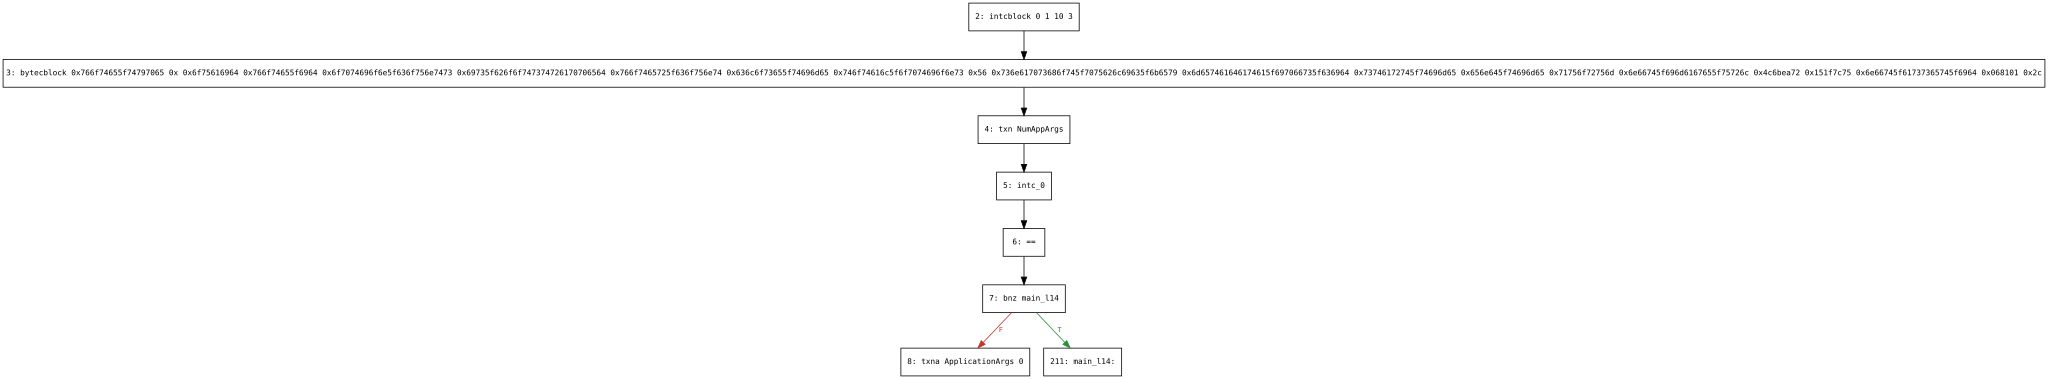

In [11]:
start = entry
near = nx.single_source_shortest_path_length(cfg, start, cutoff=6).keys()
slice_g = g.subgraph(near).copy()

draw_cfg(slice_g)

## 9. Dataflow slice

Pull a self-contained dataflow region — here, the largest weakly-connected component of the dataflow subgraph. Other natural seeds: `nx.descendants(df, n)` from a specific opcode, or everything touching a given scratch slot.

In [11]:
# Pick the largest weakly-connected component of the dataflow subgraph —
# a natural "slice" that's big enough to visualize but small enough to read.
components = sorted(nx.weakly_connected_components(df), key=len, reverse=True)
df_slice = g.subgraph(components[0]).copy()
print(f"biggest dataflow component: {df_slice.number_of_nodes()} nodes, "
      f"{sum(1 for _,_,d in df_slice.edges(data=True) if d['kind']=='dataflow')} dataflow edges")

draw_dataflow(df_slice)


NameError: name 'df' is not defined

### Physical (force-directed) layout

Dataflow has no top-to-bottom structure, so the layered `dot` layout often produces tangled edges. `sfdp` / `fdp` / `neato` lay nodes out by simulating springs, which tends to surface clusters (e.g. a scratch slot's readers and writers) visually.

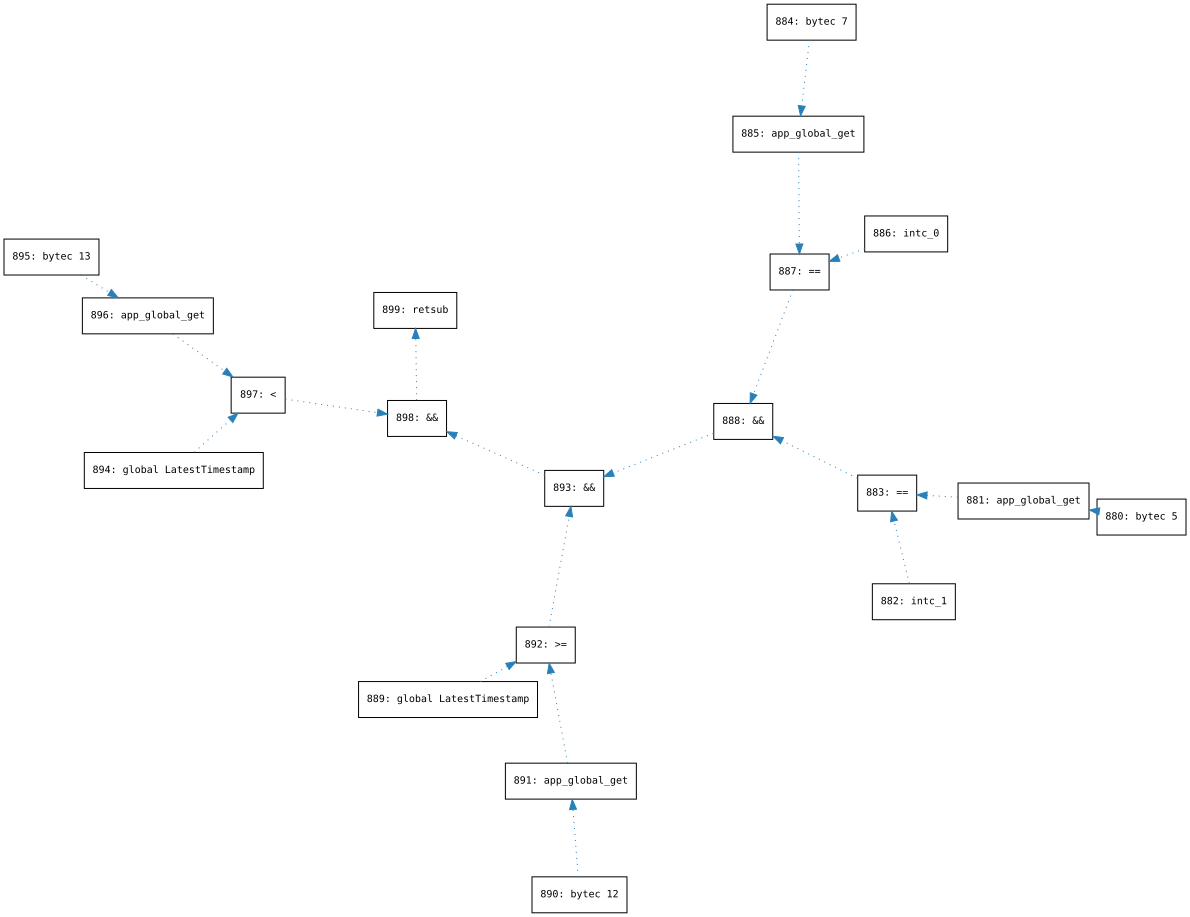

In [13]:
draw_dataflow(df_slice, engine="sfdp")


## 10. Overlay: CFG + dataflow on the same slice

Solid edges = CFG, dotted blue = dataflow.

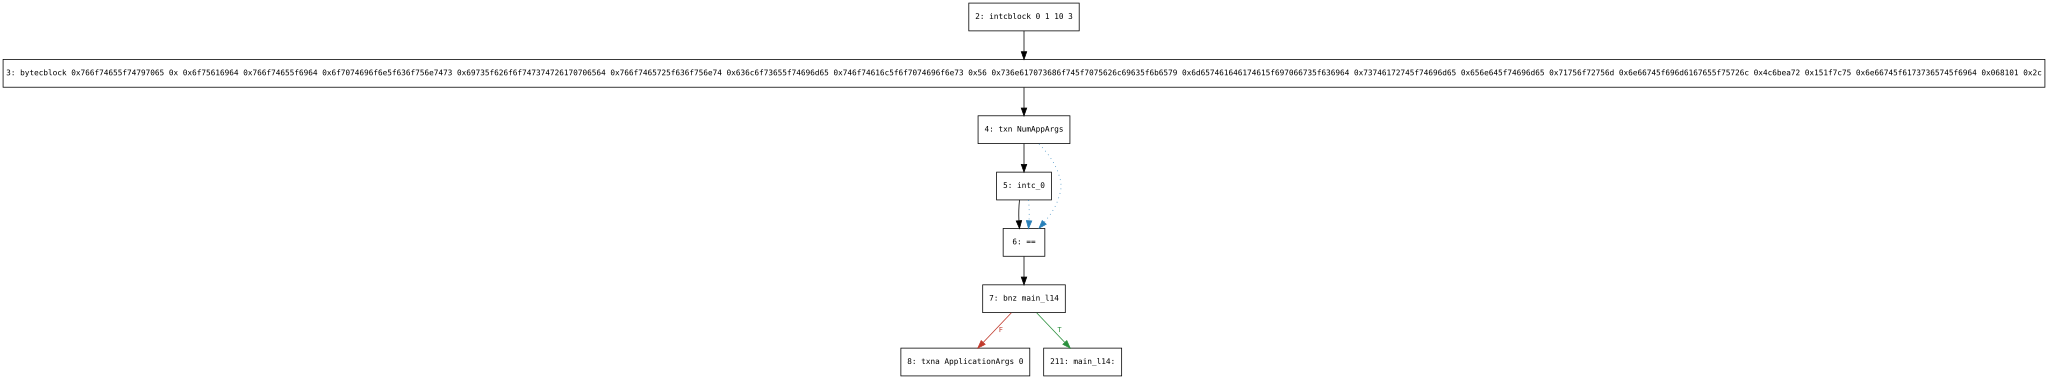

In [14]:
draw(slice_g, kinds=("cfg", "dataflow"))

## 11. Full-file CFG (for small programs)

For the ~1200-node xgov contract this is huge but legible; for larger contracts prefer slicing first.

In [15]:
files = sorted({n.location.file for n in g.nodes})
print("files:", files)

# Save to disk instead of embedding a huge SVG in the notebook.
svg = draw_cfg(g, file=files[0])
out_path = Path.home() / f"teal_cfg_{Path(files[0]).stem}.svg"
svg.save(out_path)
print("saved to", out_path)

files: ['approval.teal']


KeyboardInterrupt: 

## 11b. Basic-block view

For larger programs the per-opcode CFG is too dense for `dot` to lay out (and often OOMs). `draw_cfg_bb` collapses every basic block into a single rounded box listing its opcodes. Phi nodes are preserved as side-header ellipses attached to their host block.

The BB graph is ~10× smaller than the op-level one (xgov: 1814 → 161 BB boxes + 641 phi side-nodes = 802 nodes), which is enough for `dot` to render the whole program at once.

In [16]:
from tealtools.graphs import draw_cfg_bb, cfg_bb_graph, BasicBlockNode, PhiNode

h = cfg_bb_graph(g)
bb_count  = sum(1 for n in h.nodes if isinstance(n, BasicBlockNode))
phi_count = sum(1 for n in h.nodes if isinstance(n, PhiNode))
print(f"BB graph: {bb_count} basic blocks, {phi_count} phis, {h.number_of_edges()} edges")

# Full file at BB granularity. Save to disk — the SVG is still ~2 MiB.
svg = draw_cfg_bb(g, file=files[0])
out_path_bb = Path.home() / f"teal_cfg_{Path(files[0]).stem}_bb.svg"
svg.save(out_path_bb)
print("saved to", out_path_bb)

BB graph: 161 basic blocks, 641 phis, 1216 edges


KeyboardInterrupt: 

## 13. SSA stack per opcode

Every opcode that touches the stack gets a typed `stack_inputs` / `stack_outputs` list attached:

- **Inputs** are `Definition`s in `getStackInputByOrder` order (1-based `ord` → index 0). Each entry is either an `SSAVar` (produced by a regular write — labeled `V#{idx}@L{line}`) or a `PhiNode` (`φ_k@L{line}` for direct, `φᵢ_k@L{line}` for indirect).
- **Outputs** are `SSAVar` instances, one per push, in output-index order.

Use `stack_summary(g, op)` for one-line formatting or `print_ssa_trace(g, file=..., line_range=(lo, hi))` to walk a span.

In [10]:
from tealtools.graphs import print_ssa_trace, stack_inputs, stack_outputs, SSAVar, PhiNode

# Walk the first 40 lines, showing stack in/out per opcode.
print_ssa_trace(g, file="approval.teal")

L   2: intcblock 0 1 10 3                    in=[]                                          out=[]
L   3: bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d657461646174615f697066735f636964 0x73746172745f74696d65 0x656e645f74696d65 0x71756f72756d 0x6e66745f696d6167655f75726c 0x4c6bea72 0x151f7c75 0x6e66745f61737365745f6964 0x068101 0x2c  in=[]                                          out=[]
L   4: txn NumAppArgs                        in=[]                                          out=[V#1@L4]
L   5: intc_0                                in=[]                                          out=[V#1@L5]
L   6: ==                                    in=[V#1@L5, V#1@L4]                            out=[V#1@L6]
L   7: bnz main_l14                          in=[V#1@L6]                                

In [ ]:
# Find ops that consume at least one phi as a stack input.
phi_consumers = []
for n in g.nodes:
    if not isinstance(n, T.AstNode):
        continue
    ins = stack_inputs(g, n)
    if any(isinstance(x, PhiNode) for x in ins):
        phi_consumers.append(n)

phi_consumers.sort(key=lambda n: n.location.start_line)
print(f"{len(phi_consumers)} ops consume a phi\n")

for n in phi_consumers[:5]:
    ins = stack_inputs(g, n)
    outs = stack_outputs(g, n)
    print(f"L{n.location.start_line:<4} {type(n).__name__:20s} {n.code!r}")
    for i, d in enumerate(ins, start=1):
        kind = type(d).__name__
        print(f"    in[{i}]  {kind:10s} {d!r}")
    for i, v in enumerate(outs, start=1):
        print(f"    out[{i}] SSAVar     {v!r}")

## 13b. Experimental: functional SSA form

Same info as `print_ssa_trace`, rewritten in a pseudo-code functional form:

```
(out1, out2) = opcode immediates (in1, in2)
```

Rules:
- No outputs → omit the `(…) =` prefix (e.g. `bnz`, `store`).
- No inputs → RHS ends with `()`.
- Immediates appear verbatim between the opcode and the input tuple, mirroring source spelling.

In [17]:
from tealtools.graphs import print_ssa_functional, ssa_functional

# Subroutine body showcasing multi-output frame_digs + nested phis.
# intc_* / bytec_* are resolved to their literal constblock values by default.
print_ssa_functional(g, file="approval.teal")

# Pass `resolve_consts=False` to keep the raw intc_*/bytec_* names.
# print_ssa_functional(g, file="approval.teal", line_range=(225, 260), resolve_consts=False)

L   2: intcblock 0 1 10 3 ()
L   3: bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d657461646174615f697066735f636964 0x73746172745f74696d65 0x656e645f74696d65 0x71756f72756d 0x6e66745f696d6167655f75726c 0x4c6bea72 0x151f7c75 0x6e66745f61737365745f6964 0x068101 0x2c ()
L   4: V#1@L4 = txn NumAppArgs ()
L   5: V#1@L5 = 0
L   6: V#1@L6 = == (V#1@L5, V#1@L4)
L   7: bnz main_l14 (V#1@L6)
L   8: V#1@L8 = txna ApplicationArgs 0 ()
L   9: V#1@L9 = pushbytes 0x101cea00 ()
L  10: V#1@L10 = == (V#1@L9, V#1@L8)
L  11: bnz main_l13 (V#1@L10)
L  12: V#1@L12 = txna ApplicationArgs 0 ()
L  13: V#1@L13 = pushbytes 0x5d4cf066 ()
L  14: V#1@L14 = == (V#1@L13, V#1@L12)
L  15: bnz main_l12 (V#1@L14)
L  16: V#1@L16 = txna ApplicationArgs 0 ()
L  17: V#1@L17 = pushbytes 0xa4e8d164 ()
L  18: V#1@L18 = == (V

## 12. Lower-level: raw DOT source

If you want to post-process the DOT (e.g. group nodes by subroutine into clusters), use `to_dot` directly.

In [14]:
dot_src = to_dot(slice_g, kinds=("cfg",))
print(dot_src[:500], "...\n")
print("total:", len(dot_src), "bytes")

digraph TEAL {
  rankdir=TB;
  overlap=false;
  splines=true;
  node [shape=box, fontname="Monospace", fontsize=10];
  edge [fontname="Monospace", fontsize=9];
  "approval.teal:2" [label="2: intcblock 0 1 10 3"];
  "approval.teal:3" [label="3: bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d65 ...

total: 1369 bytes


## 14. `teal_ssa` — typed SSA program representation

Everything shown so far lives as node attributes on the NetworkX graph. `teal_ssa.SSAProgram` wraps the same data as first-class Python objects:

- `SSAVar` — one per produced stack value, with back-refs `defined_by` (the `Assignment`) and `uses` (consumers).
- `Phi` — one per live SSA phi (backward-liveness filtered at the QL layer — see `codeql-backend/teal/ql/lib/codeql/teal/SSA/SSA.qll`). Carries `args` and `basic_block`.
- `Const` — resolved `intcblock` / `bytecblock` / push-literal value.
- `Assignment` — `outputs = op immediates (inputs)`. Pretty-prints via `.functional(resolve_consts=True/False)`.
- `BasicBlock` — `assignments` (ordered), `phis` (entry phis), `predecessors`, `successors`.

Two graph views: `data_graph()` (data-dependency DAG over SSAVars/Phis/Assignments) and `cfg()` (BB-level NetworkX graph).

In [12]:
from tealtools.ssa import SSAProgram, Assignment, SSAVar as SSA_SSAVar, Phi, BasicBlock

p = SSAProgram(DB)
print(f"{len(p)} assignments, {len(p.vars)} SSA vars, {len(p.phis)} live phis, {len(p.blocks)} basic blocks")

1109 assignments, 1673 SSA vars, 347 live phis, 161 basic blocks


### Per-block functional dump

`functional_by_block` prints each BB as a labeled header (with pred/succ line numbers) followed by its phis and assignments. Great for reading structure at a glance — here, the first `itoa_1` subroutine.

In [15]:
# Filter the per-block dump to the subroutine range we've been exploring.
# (functional_by_block walks *all* BBs in the file — we slice on the output.)
out = p.functional_by_block(file="approval.teal").split("\n\n")
shown = [chunk for chunk in out if chunk.startswith("# BB(") and
         225 <= int(chunk.split("L")[1].split("-")[0]) <= 260]
print("\n\n".join(shown))

ValueError: invalid literal for int() with base 10: '8, '

### Object-graph navigation

Because each `SSAVar` knows its `defined_by` and `uses`, you can walk backward from a sink or forward from a source. Below: pick the `concat` at L254 and show the transitive def-chain that produced each of its inputs.

In [18]:
from tealtools.ssa import Const

def def_chain(operand, depth=0, max_depth=4):
    """Print the transitive defining assignment(s) for an operand."""
    indent = "  " * depth
    if isinstance(operand, Const):
        print(f"{indent}{operand!r}")
        return
    if isinstance(operand, Phi):
        print(f"{indent}{operand!r}  (phi at {operand.basic_block})")
        if depth < max_depth:
            for a in operand.args:
                def_chain(a, depth + 1, max_depth)
        return
    # SSAVar
    print(f"{indent}{operand!r}  <-  {operand.defined_by!r}")
    if depth < max_depth and operand.defined_by is not None:
        for inp in operand.defined_by.inputs:
            def_chain(inp, depth + 1, max_depth)

# Pick the concat at L254 — its inputs are two phis (one nested indirect).
concat = next(a for a in p if a.location.file == "approval.teal"
              and a.location.line == 254 and a.op == "concat")
print(f"{concat!r}\n")
for i, inp in enumerate(concat.inputs, start=1):
    print(f"input {i}:")
    def_chain(inp, depth=1)
    print()

V#1@L254 = concat (phi(phi(V#2@L250)), phi(V#1@L233))

input 1:
  phi(phi(V#2@L250))  (phi at BB(approval.teal:254-255))
    phi(V#2@L250)  (phi at BB(approval.teal:227-233))
      V#2@L250  <-  V#1@L250, V#2@L250, V#3@L250 = frame_dig -1 (phi(phi(V#2@L242)), phi(V#1@L248))
        phi(phi(V#2@L242))  (phi at BB(approval.teal:249-253))
        phi(V#1@L248)  (phi at BB(approval.teal:249-253))

input 2:
  phi(V#1@L233)  (phi at BB(approval.teal:254-255))
    V#1@L233  <-  V#1@L233 = retsub (V#1@L232, V#3@L230)
      V#1@L232  <-  V#1@L232 = extract3 (V#1@L231, V#1@L230, V#2@L230)
        V#1@L231  <-  V#1@L231 = 1
        V#1@L230  <-  V#1@L230, V#2@L230, V#3@L230 = frame_dig -1 (V#1@L229, phi(V#1@L252))
        V#2@L230  <-  V#1@L230, V#2@L230, V#3@L230 = frame_dig -1 (V#1@L229, phi(V#1@L252))
      V#3@L230  <-  V#1@L230, V#2@L230, V#3@L230 = frame_dig -1 (V#1@L229, phi(V#1@L252))
        V#1@L229  <-  V#1@L229 = pushbytes 0x30313233343536373839 ()
        phi(V#1@L252)  (phi at BB(ap

### Whole-program functional graph

`p.draw()` renders the BB-level CFG, with each BB labeled by its functional-form assignments (phis as entry header, opcodes below). Full program fits since we're at BB granularity — ~161 boxes on xgov.

In [ ]:
# Render the full program. SVG is large (~3 MiB) so save to disk rather
# than embedding inline.
svg = p.draw(file="approval.teal")
out_functional = Path.home() / "teal_functional_approval.svg"
svg.save(out_functional)
print("saved to", out_functional)

saved to /home/argi/teal_functional_approval.svg


### `materialize_phis()` — out-of-SSA lowering

Converts each live phi into a materialized variable (`mat_phi_k`, k monotonically increasing). For every DirectPhi argument `v_i`, inserts a copy assignment `mat_phi_k = v_i` right at `v_i`'s def site. Every consumer that used to read the phi now reads the `mat_phi_k` directly. IndirectPhis share the `mat_phi` of their root DirectPhi — no new variable allocated.

This breaks strict SSA on purpose: `mat_phi_k` has one def per incoming edge (canonical out-of-SSA form). Useful when downstream analyses want concrete value-tracking without phi semantics.

Side-by-side on a real slice from `itoa_1`:

In [ ]:
# Fresh program so we can show the before/after comparison.
p2 = teal_ssa.SSAProgram(DB)

print("=" * 78)
print(f"BEFORE materialize_phis — {len(p2)} assignments, {len(p2.phis)} phis")
print("=" * 78)
print(p2.functional(file="approval.teal", line_range=(248, 255)))

p2.materialize_phis()

print()
print("=" * 78)
print(f"AFTER  materialize_phis — {len(p2)} assignments, "
      f"{len(p2.mat_phis)} mat_phi vars")
print("=" * 78)
print(p2.functional(file="approval.teal", line_range=(248, 255)))

BEFORE materialize_phis — 1109 assignments, 347 phis
L   2: intcblock 0 1 10 3 ()
L   3: bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d657461646174615f697066735f636964 0x73746172745f74696d65 0x656e645f74696d65 0x71756f72756d 0x6e66745f696d6167655f75726c 0x4c6bea72 0x151f7c75 0x6e66745f61737365745f6964 0x068101 0x2c ()
L   4: V#1@L4 = txn NumAppArgs ()
L   5: V#1@L5 = 0
L   6: V#1@L6 = == (V#1@L5, V#1@L4)
L   7: bnz main_l14 (V#1@L6)
L   8: V#1@L8 = txna ApplicationArgs 0 ()
L   9: V#1@L9 = pushbytes 0x101cea00 ()
L  10: V#1@L10 = == (V#1@L9, V#1@L8)
L  11: bnz main_l13 (V#1@L10)
L  12: V#1@L12 = txna ApplicationArgs 0 ()
L  13: V#1@L13 = pushbytes 0x5d4cf066 ()
L  14: V#1@L14 = == (V#1@L13, V#1@L12)
L  15: bnz main_l12 (V#1@L14)
L  16: V#1@L16 = txna ApplicationArgs 0 ()
L  17: V#1

## 15. Small-contract walkthrough: `repro`A minimal ARC4-style approval program with two branches (a known method and a default-create path) that converge at `main_after_if_else@6`. The join shows up as one live phi feeding the `dup` at L15 — `phi(V#1@L33, V#1@L43)` meets the `bury 1` output from each branch.Source: `tests/projects/teal-contracts/repro/approval.teal`. Build the DB once with:```codeql database create tests/dbs/repro-db --overwrite -l teal \    -s tests/projects/teal-contracts/repro \    --search-path .codeql-extractors```

In [ ]:
REPRO_DB = HERE.parent.parent / "tests" / "dbs" / "repro-db"p_repro = teal_ssa.SSAProgram(REPRO_DB)print(f"{len(p_repro)} assignments, {len(p_repro.vars)} SSA vars, "      f"{len(p_repro.phis)} live phis, {len(p_repro.blocks)} basic blocks")print()print(p_repro.functional())

### Per-BB view with pred/succ wiringEach BB shows its line range + the preceding/following BBs. The join BB `main_after_if_else@6` at L15 has two predecessors — L33 (end of known-method branch) and L43 (end of default-create branch) — and the phi at that BB carries both.

In [ ]:
print(p_repro.functional_by_block())

### After `materialize_phis()`The single phi at L15 is replaced by `mat_phi_1`, and a copy `mat_phi_1 = V#1@L…` is inserted at each `bury 1` output on L33 and L43 — exactly the out-of-SSA form with one copy per incoming branch, same mat var on the LHS.

In [ ]:
p_repro.materialize_phis()print(p_repro.functional_by_block())

### Functional graph renderSmall enough to inline — `p.draw()` returns an SVG that Jupyter displays directly.

In [ ]:
# Fresh program (pre-materialization) so the graph shows the phi.p_repro_fresh = teal_ssa.SSAProgram(REPRO_DB)p_repro_fresh.draw()

## 16. Constant propagation pass`SSAProgram.propagate_constants()` walks the program once and resolves each `SSAVar` and `Phi` to a literal value when statically derivable:- An `SSAVar` is constant when its defining `Assignment` is a constblock-pusher (`intc_*` / `bytec_*`) and the constblock entry is resolved.- A `Phi` is constant when *every* arg (recursively, through phi chains) resolves to the **same** literal. Iterates to fixed point.The pass attaches `.const_value` on each resolved var/phi. `Assignment.functional()` then substitutes constants for variable identifiers when rendering inputs. Pass `propagate_consts=False` to keep the raw SSA names.Below: full xgov approval program with constants propagated. Saved to disk because the output is large (~1100 assignments).

In [ ]:
# Fresh SSAProgram so the propagation runs from a clean state.p_xgov = teal_ssa.SSAProgram(DB)const_vars_before = sum(1 for v in p_xgov.vars.values() if v.const_value is not None)const_phis_before = sum(1 for ph in p_xgov.phis.values() if ph.const_value is not None)print(f"before: {const_vars_before} constant SSA vars, {const_phis_before} constant phis")p_xgov.propagate_constants()const_vars = sum(1 for v in p_xgov.vars.values() if v.const_value is not None)const_phis = sum(1 for ph in p_xgov.phis.values() if ph.const_value is not None)print(f"after:  {const_vars} constant SSA vars ({const_vars/len(p_xgov.vars):.0%} of all), "      f"{const_phis} constant phis ({const_phis/len(p_xgov.phis):.0%} of all)")# Render the whole program with constants substituted in inputs.out_path = Path.home() / "teal_xgov_constprop.txt"out_path.write_text(p_xgov.functional(file="approval.teal"))print(f"saved: {out_path}  ({out_path.stat().st_size / 1024:.1f} KiB)")

### Inline previewShowing a representative slice — the entry switch (intc_0 = 0 used as comparison key) and the first prep block — so you can see propagation in action without flooding the cell.

In [ ]:
print(p_xgov.functional(file="approval.teal", line_range=(1, 60)))

### Side-by-side: with vs without propagation

In [ ]:
raw  = p_xgov.functional(file="approval.teal", line_range=(35, 41), propagate_consts=False).splitlines()prop = p_xgov.functional(file="approval.teal", line_range=(35, 41)).splitlines()for r, q in zip(raw, prop):    print(f"{r:<60}    {q}")

## 17. Dead-constant elimination`SSAProgram.eliminate_dead_constants()` is a follow-up pass that **inlines** every constant-resolved SSAVar/Phi reference into its consumer's input list, then **drops** the now-orphan SSAVars/Phis and any Assignment whose every output is dead. It implicitly runs `propagate_constants()` first if not already done.Conservative: only touches things with `const_value` set. Non-constant producers (`txn` reads, `load N`, function calls, etc.) are kept even if their only consumer was dropped — their AST node carries side-effect / source meaning we want to preserve.Net effect: trivial constant pushes (`L 5: V#1@L5 = 0`) disappear from the trace; consumers already render the inlined literal.Note: `propagate_constants()` now uses the dataflow-aware `tryAsInt` / `tryAsBytes` libraries from `codeql-backend/teal/ql/lib/codeql/teal/dataflow/` — coverage walks arithmetic folds, scratch-slot reads, callsub/retsub bridges, and phi convergence, not just direct constblock pushes.

In [ ]:
# Fresh program so we can show the before / after side by side.p_xgov_dce = teal_ssa.SSAProgram(DB)before_count = (len(p_xgov_dce), len(p_xgov_dce.vars), len(p_xgov_dce.phis))p_xgov_dce.propagate_constants()p_xgov_dce.eliminate_dead_constants()after_count  = (len(p_xgov_dce), len(p_xgov_dce.vars), len(p_xgov_dce.phis))print(f"before: {before_count[0]} assignments, {before_count[1]} SSA vars, {before_count[2]} phis")print(f"after:  {after_count[0]} assignments  ({before_count[0]-after_count[0]} dropped),")print(f"        {after_count[1]} SSA vars     ({before_count[1]-after_count[1]} dropped),")print(f"        {after_count[2]} phis         ({before_count[2]-after_count[2]} dropped)")# Save the trimmed full-program trace.out_path = Path.home() / "teal_xgov_constprop_dce.txt"out_path.write_text(p_xgov_dce.functional(file="approval.teal"))print(f"saved: {out_path}  ({out_path.stat().st_size / 1024:.1f} KiB)")

### Same itoa_1 slice, before vs after DCE`p_xgov` (from section 16) had `propagate_constants()` only; `p_xgov_dce` has the additional DCE pass.

In [ ]:
left  = p_xgov.functional(file="approval.teal", line_range=(228, 260)).splitlines()right = p_xgov_dce.functional(file="approval.teal", line_range=(228, 260)).splitlines()# Right side may be shorter (some lines dropped) — pad with blanks.width = max(len(l) for l in left)max_lines = max(len(left), len(right))left  += [""] * (max_lines - len(left))right += [""] * (max_lines - len(right))print(f"{'PROPAGATE ONLY':<{width}}    DCE")print("-" * (width * 2 + 4))for l, r in zip(left, right):    print(f"{l:<{width}}    {r}")